# 🎯 Resume / Candidate Screening System
## Future Interns - Machine Learning Task 3 (2026)

---

### 📌 Project Overview
This notebook builds a complete **ML-based Resume Screening System** that:
- Reads resume data from real Kaggle datasets
- Cleans and preprocesses text using NLP
- Extracts skills from resumes and job descriptions
- Scores each candidate using TF-IDF similarity
- Ranks candidates based on job role fit
- Identifies skill gaps for each candidate
- Visualizes results with charts

### 📁 Datasets Used
1. **Resume.csv** - Kaggle Resume Dataset (real resumes)
2. **job_descriptions.csv** - Job Roles & Skills Dataset
3. **monster_com-job_sample.csv** - Real Monster.com Job Listings

---

## PART 1: Import Libraries
**What this does:** We import all the Python libraries we need.
- `pandas` - for reading and handling CSV data
- `numpy` - for numerical operations
- `re` - for text cleaning using regular expressions
- `nltk` - Natural Language Toolkit for text preprocessing
- `sklearn` - for TF-IDF vectorization and similarity scoring
- `matplotlib / seaborn` - for creating charts and visualizations

In [1]:
# ============================================================
# PART 1: IMPORT ALL LIBRARIES
# ============================================================

import pandas as pd                  # Data handling
import numpy as np                   # Numerical operations
import re                            # Text cleaning
import nltk                          # NLP toolkit
import matplotlib.pyplot as plt      # Charts
import seaborn as sns                # Better charts
import warnings

from nltk.corpus import stopwords                              # Common words to remove
from sklearn.feature_extraction.text import TfidfVectorizer   # Convert text to numbers
from sklearn.metrics.pairwise import cosine_similarity         # Find similarity between texts

warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print('=' * 55)
print('  ✅ All Libraries Imported Successfully!')
print('=' * 55)
print(f'  Pandas   version : {pd.__version__}')
print(f'  Numpy    version : {np.__version__}')
print(f'  NLTK     version : {nltk.__version__}')
print('=' * 55)

  ✅ All Libraries Imported Successfully!
  Pandas   version : 3.0.0
  Numpy    version : 2.1.3
  NLTK     version : 3.9.4


## PART 2: Load Datasets
**What this does:** We load all 3 CSV/Excel files into pandas DataFrames.
- A DataFrame is like a table (rows and columns) in Python
- We check what columns each file has
- We handle errors if a file is missing or has encoding issues
- **Dataset 1** = Resumes (candidates)
- **Dataset 2** = Job descriptions with required skills
- **Dataset 3** = Real Monster.com job postings

In [2]:
# ============================================================
# PART 2: LOAD ALL 3 DATASETS (FIXED)
# ============================================================

print('📂 Loading Datasets...\n')

# ---------- DATASET 1: RESUMES ----------
try:
    resume_df = pd.read_csv('data/Resume.csv', encoding='utf-8')
    print(f'✅ Dataset 1 - Resume loaded! Rows: {len(resume_df)}')
    print(f'   Columns: {list(resume_df.columns)}\n')
except:
    try:
        resume_df = pd.read_csv('data/Resume.csv', encoding='latin1')
        print(f'✅ Dataset 1 - Resume loaded! Rows: {len(resume_df)}\n')
    except Exception as e:
        print(f'❌ Dataset 1 failed: {e}')
        resume_df = None

# ---------- DATASET 2: JOB DESCRIPTIONS ----------
try:
    job_df = pd.read_csv('data/job_descriptions.csv', encoding='utf-8')
    print(f'✅ Dataset 2 - Job Descriptions loaded! Rows: {len(job_df)}')
    print(f'   Columns: {list(job_df.columns)}\n')
except:
    try:
        job_df = pd.read_csv('data/job_descriptions.csv', encoding='latin1')
        print(f'✅ Dataset 2 loaded! Rows: {len(job_df)}\n')
    except Exception as e:
        print(f'❌ Dataset 2 failed: {e}')
        job_df = None

# ---------- DATASET 3: MONSTER.COM ----------
try:
    monster_df = pd.read_csv('data/monster_com-job_sample.csv', encoding='utf-8')
    print(f'✅ Dataset 3 - Monster Jobs loaded! Rows: {len(monster_df)}')
    print(f'   Columns: {list(monster_df.columns)}\n')
except:
    try:
        monster_df = pd.read_csv('data/monster_com-job_sample.csv', encoding='latin1')
        print(f'✅ Dataset 3 loaded! Rows: {len(monster_df)}\n')
    except Exception as e:
        print(f'❌ Dataset 3 failed: {e}')
        monster_df = None

print('=' * 55)
print('  📊 All Datasets Loading Complete!')
print('=' * 55)

📂 Loading Datasets...

✅ Dataset 1 - Resume loaded! Rows: 2484
   Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

✅ Dataset 2 - Job Descriptions loaded! Rows: 1615940
   Columns: ['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']

✅ Dataset 3 - Monster Jobs loaded! Rows: 22000
   Columns: ['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']

  📊 All Datasets Loading Complete!


In [3]:
import os

# Check current working directory
print("Current folder:", os.getcwd())
print()

# Check what's in data folder
print("Files in data folder:")
try:
    files = os.listdir('data')
    for f in files:
        print(f"  - {f}")
except:
    print("  data folder nahi mila!")
    
print()

# Check data folder exists or not
print("data folder exists?", os.path.exists('data'))
print("Resume.csv exists?", os.path.exists('data/Resume.csv'))

Current folder: c:\Users\KIIT0001\Downloads\FUTURE_ML_03

Files in data folder:
  - job_descriptions.csv
  - monster_com-job_sample.csv
  - Resume.csv

data folder exists? True
Resume.csv exists? True


## PART 3: Explore the Data
**What this does:** Before building anything, we look at what our data actually contains.
- `head()` shows first 5 rows of the dataset
- `shape` tells us rows and columns count
- `info()` tells us data types and missing values
- This step is called **Exploratory Data Analysis (EDA)**
- It helps us understand which columns have the resume text we need

In [4]:
# ============================================================
# PART 3: EXPLORE DATA - See what's inside each dataset
# ============================================================

print('=' * 55)
print('  DATASET 1: RESUME DATA - First Look')
print('=' * 55)

if resume_df is not None:
    print(f'Shape: {resume_df.shape[0]} rows x {resume_df.shape[1]} columns\n')
    print('First 3 rows:')
    display(resume_df.head(3))
    print(f'\nMissing values per column:')
    print(resume_df.isnull().sum())
    
    # Show unique categories if column exists
    for col in ['Category', 'category', 'Job Title', 'job_title']:
        if col in resume_df.columns:
            print(f'\nUnique Categories: {resume_df[col].nunique()}')
            print(resume_df[col].value_counts().head(10))
            break

  DATASET 1: RESUME DATA - First Look
Shape: 2484 rows x 4 columns

First 3 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR



Missing values per column:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Unique Categories: 24
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
Name: count, dtype: int64


In [5]:
print('=' * 55)
print('  DATASET 2: JOB DESCRIPTIONS - First Look')
print('=' * 55)

if job_df is not None:
    print(f'Shape: {job_df.shape[0]} rows x {job_df.shape[1]} columns\n')
    print('First 3 rows:')
    display(job_df.head(3))
    print(f'\nColumn data types:')
    print(job_df.dtypes)

  DATASET 2: JOB DESCRIPTIONS - First Look
Shape: 1615940 rows x 23 columns

First 3 rows:


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."



Column data types:
Job Id                int64
Experience              str
Qualifications          str
Salary Range            str
location                str
Country                 str
latitude            float64
longitude           float64
Work Type               str
Company Size          int64
Job Posting Date        str
Preference              str
Contact Person          str
Contact                 str
Job Title               str
Role                    str
Job Portal              str
Job Description         str
Benefits                str
skills                  str
Responsibilities        str
Company                 str
Company Profile         str
dtype: object


In [6]:
print('=' * 55)
print('  DATASET 3: MONSTER.COM JOBS - First Look')
print('=' * 55)

if monster_df is not None:
    print(f'Shape: {monster_df.shape[0]} rows x {monster_df.shape[1]} columns\n')
    print('First 3 rows:')
    display(monster_df.head(3))
    print(f'\nColumn data types:')
    print(monster_df.dtypes)

  DATASET 3: MONSTER.COM JOBS - First Look
Shape: 22000 rows x 14 columns

First 3 rows:


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0



Column data types:
country            str
country_code       str
date_added         str
has_expired        str
job_board          str
job_description    str
job_title          str
job_type           str
location           str
organization       str
page_url           str
salary             str
sector             str
uniq_id            str
dtype: object


## PART 4: Text Cleaning & Preprocessing
**What this does:** Raw resume text is messy - it has URLs, emails, special characters, numbers, and common words like 'the', 'is', 'and' that don't help our model.
- We remove all unnecessary characters
- We convert everything to lowercase
- We remove **stopwords** (common English words that carry no meaning)
- This process is called **Text Preprocessing** in NLP
- Clean text = better model accuracy

In [7]:
# ============================================================
# PART 4: TEXT CLEANING FUNCTION
# ============================================================

def clean_text(text):
    """
    Cleans raw resume/job description text.
    
    Steps:
    1. Convert to lowercase
    2. Remove URLs (http://...)
    3. Remove email addresses
    4. Remove numbers
    5. Remove special characters (!@#$ etc)
    6. Remove extra spaces
    7. Remove stopwords (the, is, and, etc.)
    """
    
    # Handle empty/null values
    if pd.isna(text) or str(text).strip() == '':
        return ''
    
    text = str(text)
    text = text.lower()                              # Step 1: Lowercase
    text = re.sub(r'http\S+|www\S+', ' ', text)     # Step 2: Remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)            # Step 3: Remove emails
    text = re.sub(r'\d+', ' ', text)                # Step 4: Remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)            # Step 5: Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()        # Step 6: Remove extra spaces
    
    # Step 7: Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [word for word in tokens 
              if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)


# ---- TEST THE FUNCTION ----
sample_text = """John Smith - Data Scientist! 
Email: john@gmail.com | Phone: 9876543210
Skills: Python, Machine Learning, TensorFlow, SQL
Experience: 3 years at ABC Corp. Visit: https://linkedin.com/john"""

print('BEFORE CLEANING:')
print(sample_text)
print()
print('AFTER CLEANING:')
print(clean_text(sample_text))
print()
print('✅ Text Cleaning Function is Ready!')

BEFORE CLEANING:
John Smith - Data Scientist! 
Email: john@gmail.com | Phone: 9876543210
Skills: Python, Machine Learning, TensorFlow, SQL
Experience: 3 years at ABC Corp. Visit: https://linkedin.com/john

AFTER CLEANING:
john smith data scientist email phone skills python machine learning tensorflow sql experience years abc corp visit

✅ Text Cleaning Function is Ready!


## PART 5: Skills Database & Skill Extraction
**What this does:** We create a database of known tech skills organized by category.
- Then we scan each resume to find which skills are mentioned
- This is called **Keyword Extraction** in NLP
- We check for programming languages, ML tools, cloud platforms, etc.
- Result: For each resume, we get a list of skills found

In [8]:
# ============================================================
# PART 5: SKILLS DATABASE & EXTRACTION
# ============================================================

# Our master skills database - organized by category
SKILLS_DB = {
    'Programming Languages': [
        'python', 'java', 'javascript', 'c++', 'c#', 'r', 'sql',
        'html', 'css', 'php', 'swift', 'kotlin', 'golang', 'ruby',
        'scala', 'typescript', 'matlab', 'bash', 'perl'
    ],
    'Machine Learning & AI': [
        'machine learning', 'deep learning', 'neural network', 'nlp',
        'computer vision', 'tensorflow', 'pytorch', 'keras',
        'scikit-learn', 'xgboost', 'random forest', 'regression',
        'classification', 'clustering', 'natural language processing',
        'artificial intelligence', 'reinforcement learning',
        'gradient boosting', 'naive bayes', 'svm', 'lstm'
    ],
    'Data Science & Analytics': [
        'pandas', 'numpy', 'matplotlib', 'seaborn', 'tableau',
        'power bi', 'excel', 'data analysis', 'data science',
        'data visualization', 'statistics', 'big data',
        'hadoop', 'spark', 'etl', 'data mining', 'feature engineering'
    ],
    'Cloud & DevOps': [
        'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'git',
        'github', 'ci/cd', 'linux', 'devops', 'cloud computing',
        'jenkins', 'terraform', 'ansible', 'heroku'
    ],
    'Web & Databases': [
        'react', 'angular', 'vue', 'node.js', 'django', 'flask',
        'spring', 'rest api', 'graphql', 'mongodb', 'mysql',
        'postgresql', 'firebase', 'redis', 'elasticsearch'
    ],
    'Soft Skills': [
        'leadership', 'communication', 'teamwork', 'problem solving',
        'project management', 'agile', 'scrum', 'presentation',
        'critical thinking', 'collaboration'
    ]
}

# Flatten all skills into one list
ALL_SKILLS = [skill for category in SKILLS_DB.values() for skill in category]


def extract_skills(text):
    """
    Scans resume/JD text and finds matching skills.
    Returns:
        found_skills - flat list of all skills found
        by_category  - skills grouped by category
    """
    text_lower = str(text).lower()
    found_skills = []
    by_category = {}
    
    for category, skills in SKILLS_DB.items():
        matched = []
        for skill in skills:
            # Check if skill appears in text
            if re.search(r'\b' + re.escape(skill) + r'\b', text_lower):
                matched.append(skill)
                found_skills.append(skill)
        if matched:
            by_category[category] = matched
    
    return list(set(found_skills)), by_category


# ---- TEST SKILL EXTRACTION ----
test_resume = """
Experienced Data Scientist with 3 years of experience.
Skills: Python, TensorFlow, PyTorch, Machine Learning, Deep Learning,
NLP, Pandas, NumPy, SQL, AWS, Docker, Git, Data Visualization,
Scikit-learn, Statistics, Communication, Leadership.
"""

skills_found, skills_by_cat = extract_skills(test_resume)

print('SKILL EXTRACTION TEST')
print('=' * 55)
print(f'Total Skills Found: {len(skills_found)}')
print()
for category, skills in skills_by_cat.items():
    print(f'  {category}:')
    print(f'    → {", ".join(skills)}')

print()
print(f'Total skills in our database: {len(ALL_SKILLS)}')
print('✅ Skill Extraction Function Ready!')

SKILL EXTRACTION TEST
Total Skills Found: 17

  Programming Languages:
    → python, sql
  Machine Learning & AI:
    → machine learning, deep learning, nlp, tensorflow, pytorch, scikit-learn
  Data Science & Analytics:
    → pandas, numpy, data visualization, statistics
  Cloud & DevOps:
    → aws, docker, git
  Soft Skills:
    → leadership, communication

Total skills in our database: 97
✅ Skill Extraction Function Ready!


## PART 6: Build the Job Description
**What this does:** We extract a real job description from our Monster.com dataset (Dataset 3).
- We filter jobs related to Data Science / ML
- We combine top job postings to create a comprehensive JD
- This JD becomes our **benchmark** - all resumes will be compared against it
- We also extract required skills from this JD

In [9]:
# ============================================================
# PART 6: BUILD JOB DESCRIPTION FROM DATASETS
# ============================================================

print('📋 Building Job Description from Real Data...\n')

JOB_ROLE = 'Data Scientist / Machine Learning Engineer'
job_description = ''

# --- Try Dataset 3: Monster.com ---
if monster_df is not None:
    # Find the description column
    desc_col = None
    for col in ['job_description', 'description', 'job_summary',
                'summary', 'Description', 'JobDescription']:
        if col in monster_df.columns:
            desc_col = col
            break
    
    if desc_col:
        # Filter Data Science related jobs
        keywords = 'data scientist|machine learning|data analyst|python|artificial intelligence'
        mask = monster_df[desc_col].str.contains(keywords, case=False, na=False)
        filtered_jobs = monster_df[mask]
        
        if len(filtered_jobs) > 0:
            # Combine top 3 relevant job descriptions
            job_description = ' '.join(
                filtered_jobs[desc_col].dropna().head(3).tolist()
            )
            print(f'✅ Job Description from Monster.com!')
            print(f'   Found {len(filtered_jobs)} relevant job postings')
            print(f'   Combined top 3 postings into one JD')
        else:
            job_description = ' '.join(monster_df[desc_col].dropna().head(3).tolist())
            print(f'✅ Using first 3 Monster.com job postings')

# --- Fallback: Dataset 2 (Job Descriptions) ---
if job_description == '' and job_df is not None:
    for col in ['Job Description', 'description', 'job_description',
                'skills', 'Qualifications']:
        if col in job_df.columns:
            job_description = ' '.join(job_df[col].dropna().head(5).tolist())
            print(f'✅ Job Description from Dataset 2 (column: {col})')
            break

# --- Fallback: Manual JD ---
if job_description == '':
    print('⚠️  Using default job description')
    job_description = """
    We are looking for a Data Scientist and Machine Learning Engineer.
    Required Skills: Python, pandas, numpy, scikit-learn, tensorflow, pytorch,
    machine learning, deep learning, NLP, natural language processing,
    data visualization, matplotlib, seaborn, SQL, statistics, git, github,
    aws, docker, data analysis, regression, classification, clustering,
    communication, problem solving, teamwork, leadership, agile.
    Experience with big data, spark, tableau, power bi is a plus.
    """

# Extract required skills from JD
jd_skills, jd_skills_by_cat = extract_skills(job_description)

print()
print(f'🎯 Job Role: {JOB_ROLE}')
print(f'📝 JD Length: {len(job_description.split())} words')
print(f'🛠️  Required Skills Found in JD: {len(jd_skills)}')
print()
print('Required Skills by Category:')
for cat, skills in jd_skills_by_cat.items():
    print(f'  {cat}: {", ".join(skills[:5])}')

print()
print('✅ Job Description Ready!')

📋 Building Job Description from Real Data...

✅ Job Description from Monster.com!
   Found 250 relevant job postings
   Combined top 3 postings into one JD

🎯 Job Role: Data Scientist / Machine Learning Engineer
📝 JD Length: 1359 words
🛠️  Required Skills Found in JD: 15

Required Skills by Category:
  Programming Languages: python, java, r, sql, swift
  Data Science & Analytics: excel
  Cloud & DevOps: aws, azure, linux, cloud computing, ansible
  Web & Databases: postgresql
  Soft Skills: communication

✅ Job Description Ready!


## PART 7: Prepare Resume Data
**What this does:** We prepare our main resume dataset for screening.
- Identify which column contains the actual resume text
- Remove rows with empty/null resume text
- Sample a manageable number (100 resumes) for faster processing
- Apply our cleaning function to all resumes
- This is called **Data Preprocessing** - making raw data ready for the model

In [10]:
# ============================================================
# PART 7: PREPARE RESUME DATA FOR SCREENING
# ============================================================

print('🔧 Preparing Resume Data...\n')

if resume_df is not None:
    df = resume_df.copy()
    
    # Step 1: Find the resume text column
    text_col = None
    for col in ['Resume', 'resume_text', 'resume', 'text',
                'Resume_str', 'description', 'Text']:
        if col in df.columns:
            text_col = col
            break
    
    if text_col is None:
        # Use column with most text content
        text_col = df.apply(lambda col: col.astype(str).str.len().mean()).idxmax()
    
    print(f'✅ Resume text column identified: "{text_col}"')
    
    # Step 2: Remove rows with empty resume text
    df = df.dropna(subset=[text_col])
    df = df[df[text_col].str.strip() != '']
    print(f'✅ After removing empty rows: {len(df)} resumes')
    
    # Step 3: Sample 100 resumes (for fast processing)
    if len(df) > 100:
        df = df.sample(100, random_state=42).reset_index(drop=True)
        print(f'✅ Sampled 100 resumes for processing')
    else:
        df = df.reset_index(drop=True)
        print(f'✅ Using all {len(df)} resumes')
    
    # Step 4: Create candidate names
    df['Candidate_Name'] = [f'Candidate_{i+1}' for i in range(len(df))]
    
    # Step 5: Clean all resume texts
    print('\n🧹 Cleaning resume texts...')
    df['Clean_Resume'] = df[text_col].apply(clean_text)
    print(f'✅ All {len(df)} resumes cleaned!')
    
    # Step 6: Show a sample
    print('\nSample - Original vs Cleaned:')
    print('-' * 55)
    sample_orig = str(df[text_col].iloc[0])[:200]
    sample_clean = str(df['Clean_Resume'].iloc[0])[:200]
    print(f'Original : {sample_orig}...')
    print()
    print(f'Cleaned  : {sample_clean}...')

else:
    print('⚠️  Resume.csv not found - Creating sample dataset')
    sample_data = [
        {'Candidate_Name': 'Rahul Kumar', 'Resume': 'Python tensorflow pytorch deep learning machine learning NLP scikit-learn pandas numpy SQL aws docker git data science statistics classification regression'},
        {'Candidate_Name': 'Priya Sharma', 'Resume': 'Python data analysis pandas matplotlib seaborn tableau power bi SQL statistics excel data visualization communication leadership'},
        {'Candidate_Name': 'Amit Singh', 'Resume': 'Python machine learning random forest xgboost classification clustering regression scikit-learn pandas numpy matplotlib git statistics'},
        {'Candidate_Name': 'Sneha Patel', 'Resume': 'JavaScript react node.js html css mongodb rest api git agile communication teamwork problem solving'},
        {'Candidate_Name': 'Vikram Rao', 'Resume': 'AWS azure docker kubernetes linux jenkins devops ci/cd terraform python bash cloud computing git'},
        {'Candidate_Name': 'Ananya Das', 'Resume': 'Python NLP natural language processing tensorflow keras deep learning lstm text classification sentiment analysis pandas numpy'},
        {'Candidate_Name': 'Rohan Mehta', 'Resume': 'Java spring boot rest api mysql postgresql docker kubernetes microservices git agile scrum communication'},
        {'Candidate_Name': 'Kavya Reddy', 'Resume': 'Python data science machine learning pandas numpy matplotlib scikit-learn statistics sql data visualization communication presentation'},
    ]
    df = pd.DataFrame(sample_data)
    text_col = 'Resume'
    df['Clean_Resume'] = df[text_col].apply(clean_text)
    print(f'✅ Sample dataset created: {len(df)} candidates')

print()
print(f'🎯 Final Dataset Ready: {len(df)} candidates to screen')
print('✅ Data Preparation Complete!')

🔧 Preparing Resume Data...

✅ Resume text column identified: "Resume_str"
✅ After removing empty rows: 2483 resumes
✅ Sampled 100 resumes for processing

🧹 Cleaning resume texts...
✅ All 100 resumes cleaned!

Sample - Original vs Cleaned:
-------------------------------------------------------
Original :          PROGRAMME FINANCE ASSOCIATE       Professional Summary    Seeking a position where I can demonstrate my skills and contribute to an organization that offers professional growth. Being  produc...

Cleaned  : programme finance associate professional summary seeking position demonstrate skills contribute organization offers professional growth productive add value organisation knowledge previous experiences...

🎯 Final Dataset Ready: 100 candidates to screen
✅ Data Preparation Complete!


## PART 8: Build the Scoring Model (TF-IDF)
**What this does:** This is the CORE ML part of our system.
- **TF-IDF** = Term Frequency-Inverse Document Frequency
  - TF = How often a word appears in a resume
  - IDF = How rare/important that word is across all resumes
  - TF-IDF converts text into numbers the computer can compare
- **Cosine Similarity** = Measures how similar two documents are (0 = different, 1 = identical)
- We compare each resume with the job description and get a similarity score
- **Final Score = 60% TF-IDF similarity + 40% Skill Match**

In [11]:
# ============================================================
# PART 8: SCORING MODEL - TF-IDF + SKILL MATCHING
# ============================================================

print('🤖 Building Scoring Model...\n')

# Step 1: Clean the job description
clean_jd = clean_text(job_description)

# Step 2: Build TF-IDF Matrix
# Combine JD + all resumes into one list for vectorizer
all_texts = [clean_jd] + df['Clean_Resume'].tolist()

# TF-IDF Vectorizer - converts text to numerical matrix
vectorizer = TfidfVectorizer(
    max_features=5000,      # Use top 5000 important words
    ngram_range=(1, 2),     # Use single words AND 2-word phrases
    min_df=1                # Include words appearing at least once
)

tfidf_matrix = vectorizer.fit_transform(all_texts)

print(f'✅ TF-IDF Matrix built!')
print(f'   Matrix shape: {tfidf_matrix.shape}')
print(f'   Rows = 1 JD + {len(df)} resumes = {tfidf_matrix.shape[0]}')
print(f'   Columns = {tfidf_matrix.shape[1]} unique word features')

# Step 3: Calculate Cosine Similarity
# JD is row[0], resumes are rows[1:]
jd_vector = tfidf_matrix[0:1]          # Job Description vector
resume_vectors = tfidf_matrix[1:]       # All resume vectors

# Calculate similarity of each resume with JD
similarity_scores = cosine_similarity(jd_vector, resume_vectors)[0]

print(f'\n✅ Cosine Similarity calculated!')
print(f'   Highest similarity: {similarity_scores.max():.4f}')
print(f'   Lowest similarity : {similarity_scores.min():.4f}')
print(f'   Average similarity: {similarity_scores.mean():.4f}')

# Step 4: Full scoring function
def score_candidate(resume_text, candidate_name, tfidf_score_raw):
    """
    Calculates full score for one candidate.
    
    Score = 60% TF-IDF content match + 40% skill match
    """
    # TF-IDF score (0-100)
    tfidf_score = round(tfidf_score_raw * 100, 2)
    
    # Skill matching score
    resume_skills, _ = extract_skills(resume_text)
    
    if jd_skills:
        matched = [s for s in jd_skills if s in resume_skills]
        missing = [s for s in jd_skills if s not in resume_skills]
        skill_score = round((len(matched) / len(jd_skills)) * 100, 2)
    else:
        matched = resume_skills[:5]
        missing = []
        skill_score = 50.0
    
    # Weighted final score
    final_score = round((tfidf_score * 0.6) + (skill_score * 0.4), 2)
    
    return {
        'Candidate'       : candidate_name,
        'Final_Score'     : final_score,
        'TF_IDF_Score'    : tfidf_score,
        'Skill_Score'     : skill_score,
        'Matched_Skills'  : matched,
        'Missing_Skills'  : missing,
        'Skills_Found'    : len(resume_skills),
        'All_Skills'      : resume_skills
    }

print()
print('✅ Scoring Model Ready!')
print('   Formula: Final Score = (TF-IDF × 0.6) + (Skill Match × 0.4)')

🤖 Building Scoring Model...

✅ TF-IDF Matrix built!
   Matrix shape: (101, 5000)
   Rows = 1 JD + 100 resumes = 101
   Columns = 5000 unique word features

✅ Cosine Similarity calculated!
   Highest similarity: 0.2562
   Lowest similarity : 0.0321
   Average similarity: 0.0933

✅ Scoring Model Ready!
   Formula: Final Score = (TF-IDF × 0.6) + (Skill Match × 0.4)


## PART 9: Screen & Rank All Candidates
**What this does:** We apply our scoring model to ALL candidates.
- Loop through every resume
- Calculate TF-IDF score + Skill score for each
- Store results in a DataFrame
- Sort by Final Score (highest first) = **Ranking**
- This is the actual **ML inference / prediction** step

In [12]:
# ============================================================
# PART 9: SCREEN & RANK ALL CANDIDATES
# ============================================================

print('🔍 Screening All Candidates...\n')
print(f'Total candidates to screen: {len(df)}')
print('Processing...')

results = []

for i, (idx, row) in enumerate(df.iterrows()):
    resume_text = str(row[text_col])
    candidate_name = row['Candidate_Name']
    tfidf_raw = similarity_scores[i]
    
    # Score this candidate
    result = score_candidate(resume_text, candidate_name, tfidf_raw)
    results.append(result)
    
    # Progress bar
    if (i + 1) % 20 == 0 or (i + 1) == len(df):
        print(f'  ✓ Processed {i+1}/{len(df)} candidates...')

# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort by Final Score (highest first) = RANKING
results_df = results_df.sort_values('Final_Score', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print()
print('=' * 55)
print('  ✅ SCREENING COMPLETE!')
print('=' * 55)
print(f'  Total Screened : {len(results_df)} candidates')
print(f'  Highest Score  : {results_df["Final_Score"].max():.1f}/100')
print(f'  Lowest Score   : {results_df["Final_Score"].min():.1f}/100')
print(f'  Average Score  : {results_df["Final_Score"].mean():.1f}/100')
print('=' * 55)

# Show top 10 results table
print('\n📊 Results Preview (Top 10):')
display(results_df[['Rank', 'Candidate', 'Final_Score',
                     'TF_IDF_Score', 'Skill_Score', 'Skills_Found']].head(10))

🔍 Screening All Candidates...

Total candidates to screen: 100
Processing...
  ✓ Processed 20/100 candidates...
  ✓ Processed 40/100 candidates...
  ✓ Processed 60/100 candidates...
  ✓ Processed 80/100 candidates...
  ✓ Processed 100/100 candidates...

  ✅ SCREENING COMPLETE!
  Total Screened : 100 candidates
  Highest Score  : 20.7/100
  Lowest Score   : 1.9/100
  Average Score  : 8.6/100

📊 Results Preview (Top 10):


,Rank,Candidate,Final_Score,TF_IDF_Score,Skill_Score,Skills_Found
0,1,Candidate_77,20.70,25.62,13.33,8
1,2,Candidate_42,19.95,24.36,13.33,7
2,3,Candidate_90,19.93,19.89,20.00,9
3,4,Candidate_64,18.51,17.51,20.00,3
4,5,Candidate_76,15.94,8.79,26.67,4
5,6,Candidate_47,14.49,19.70,6.67,2
6,7,Candidate_85,14.42,10.70,20.00,7
7,8,Candidate_55,14.19,14.77,13.33,4
8,9,Candidate_63,14.07,14.56,13.33,4
9,10,Candidate_53,13.97,14.40,13.33,2


## PART 10: Display Detailed Rankings
**What this does:** We display results in a human-readable format.
- Show each candidate's rank, score, matched skills, and missing skills
- This is what a recruiter would actually read
- It explains WHY a candidate ranks higher or lower
- Missing skills = **Skill Gap** - what the candidate needs to learn

In [13]:
# ============================================================
# PART 10: DISPLAY DETAILED RANKINGS
# ============================================================

TOP_N = 10  # Show top 10 candidates

print('=' * 60)
print(f'  🏆 TOP {TOP_N} CANDIDATES FOR: {JOB_ROLE}')
print('=' * 60)

for _, row in results_df.head(TOP_N).iterrows():
    
    # Score badge
    score = row['Final_Score']
    if score >= 70:
        badge = '🟢 STRONG FIT'
    elif score >= 50:
        badge = '🟡 MODERATE FIT'
    elif score >= 30:
        badge = '🟠 WEAK FIT'
    else:
        badge = '🔴 NOT FIT'
    
    print(f'\n#{int(row["Rank"])} {row["Candidate"]}  [{badge}]')
    print(f'   ⭐ Final Score    : {row["Final_Score"]:.1f} / 100')
    print(f'   📄 Content Match  : {row["TF_IDF_Score"]:.1f} / 100  (TF-IDF)')
    print(f'   🛠️  Skill Match    : {row["Skill_Score"]:.1f} / 100')
    print(f'   🔢 Skills Found   : {row["Skills_Found"]} skills in resume')
    
    if row['Matched_Skills']:
        matched_str = ', '.join(row['Matched_Skills'][:7])
        print(f'   ✅ Matched Skills : {matched_str}')
    else:
        print(f'   ✅ Matched Skills : None')
    
    if row['Missing_Skills']:
        missing_str = ', '.join(row['Missing_Skills'][:5])
        print(f'   ❌ Missing Skills : {missing_str}')
    else:
        print(f'   ❌ Missing Skills : None - Perfect match!')
    
    print(f'   {"-" * 50}')

print()
print('✅ Ranking Complete!')

  🏆 TOP 10 CANDIDATES FOR: Data Scientist / Machine Learning Engineer

#1 Candidate_77  [🔴 NOT FIT]
   ⭐ Final Score    : 20.7 / 100
   📄 Content Match  : 25.6 / 100  (TF-IDF)
   🛠️  Skill Match    : 13.3 / 100
   🔢 Skills Found   : 8 skills in resume
   ✅ Matched Skills : linux, communication
   ❌ Missing Skills : r, cloud computing, java, bash, swift
   --------------------------------------------------

#2 Candidate_42  [🔴 NOT FIT]
   ⭐ Final Score    : 19.9 / 100
   📄 Content Match  : 24.4 / 100  (TF-IDF)
   🛠️  Skill Match    : 13.3 / 100
   🔢 Skills Found   : 7 skills in resume
   ✅ Matched Skills : communication, excel
   ❌ Missing Skills : r, cloud computing, java, linux, bash
   --------------------------------------------------

#3 Candidate_90  [🔴 NOT FIT]
   ⭐ Final Score    : 19.9 / 100
   📄 Content Match  : 19.9 / 100  (TF-IDF)
   🛠️  Skill Match    : 20.0 / 100
   🔢 Skills Found   : 9 skills in resume
   ✅ Matched Skills : sql, communication, excel
   ❌ Missing Skills : 

## PART 11: Skill Gap Analysis
**What this does:** We analyze skill gaps across ALL candidates.
- For each required skill, we check what % of candidates have it
- High coverage = common skill, many candidates have it
- Low coverage = rare skill, hard to find candidates with it
- This helps recruiters understand the talent market
- Candidates can use this to know which skills to learn next

In [14]:
# ============================================================
# PART 11: SKILL GAP ANALYSIS
# ============================================================

print('=' * 60)
print('  📉 SKILL GAP ANALYSIS - All Candidates')
print('=' * 60)
print()

if jd_skills:
    skill_coverage = {}
    
    for skill in jd_skills:
        count = sum(
            1 for skills_list in results_df['All_Skills']
            if skill in skills_list
        )
        coverage_pct = round((count / len(results_df)) * 100, 1)
        skill_coverage[skill] = coverage_pct
    
    # Sort by coverage (low to high = biggest gaps first)
    skill_coverage = dict(sorted(skill_coverage.items(), key=lambda x: x[1]))
    
    print(f'Required Skills in JD: {len(jd_skills)}')
    print(f'Total Candidates    : {len(results_df)}')
    print()
    print(f'{"Skill":<30} {"Coverage":>8}   {"Visual Bar"}')
    print('-' * 65)
    
    for skill, coverage in skill_coverage.items():
        filled = int(coverage / 5)
        bar = '█' * filled + '░' * (20 - filled)
        
        if coverage >= 60:
            icon = '✅'
        elif coverage >= 30:
            icon = '⚠️ '
        else:
            icon = '❌'
        
        print(f'{icon} {skill:<28} {coverage:>5}%   {bar}')
    
    print()
    print('Legend:')
    print('  ✅ >= 60% = Widely available skill')
    print('  ⚠️  >= 30% = Moderately available')
    print('  ❌  < 30% = RARE SKILL - Hard to find!')
    
else:
    print('No specific skills found in job description to analyze.')

print()
print('✅ Skill Gap Analysis Complete!')

  📉 SKILL GAP ANALYSIS - All Candidates

Required Skills in JD: 15
Total Candidates    : 100

Skill                          Coverage   Visual Bar
-----------------------------------------------------------------
❌ cloud computing                0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ bash                           0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ swift                          0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ python                         0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ ansible                        0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ postgresql                     0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ aws                            0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ perl                           0.0%   ░░░░░░░░░░░░░░░░░░░░
❌ java                           1.0%   ░░░░░░░░░░░░░░░░░░░░
❌ azure                          1.0%   ░░░░░░░░░░░░░░░░░░░░
❌ linux                          2.0%   ░░░░░░░░░░░░░░░░░░░░
❌ r                              7.0%   █░░░░░░░░░░░░░░░░░░░
❌ sql                            7.0%   █░░░░░░░░░░░░░░

## PART 12: Data Visualizations
**What this does:** We create 4 charts to visually present our results.
- **Chart 1** - Top candidates bar chart (who scored highest)
- **Chart 2** - Score breakdown comparison (TF-IDF vs Skill score)
- **Chart 3** - Score distribution histogram (how candidates spread)
- **Chart 4** - Skill gap bar chart (which skills are missing most)
- Visual charts make it easy for non-technical stakeholders (HR, managers) to understand results

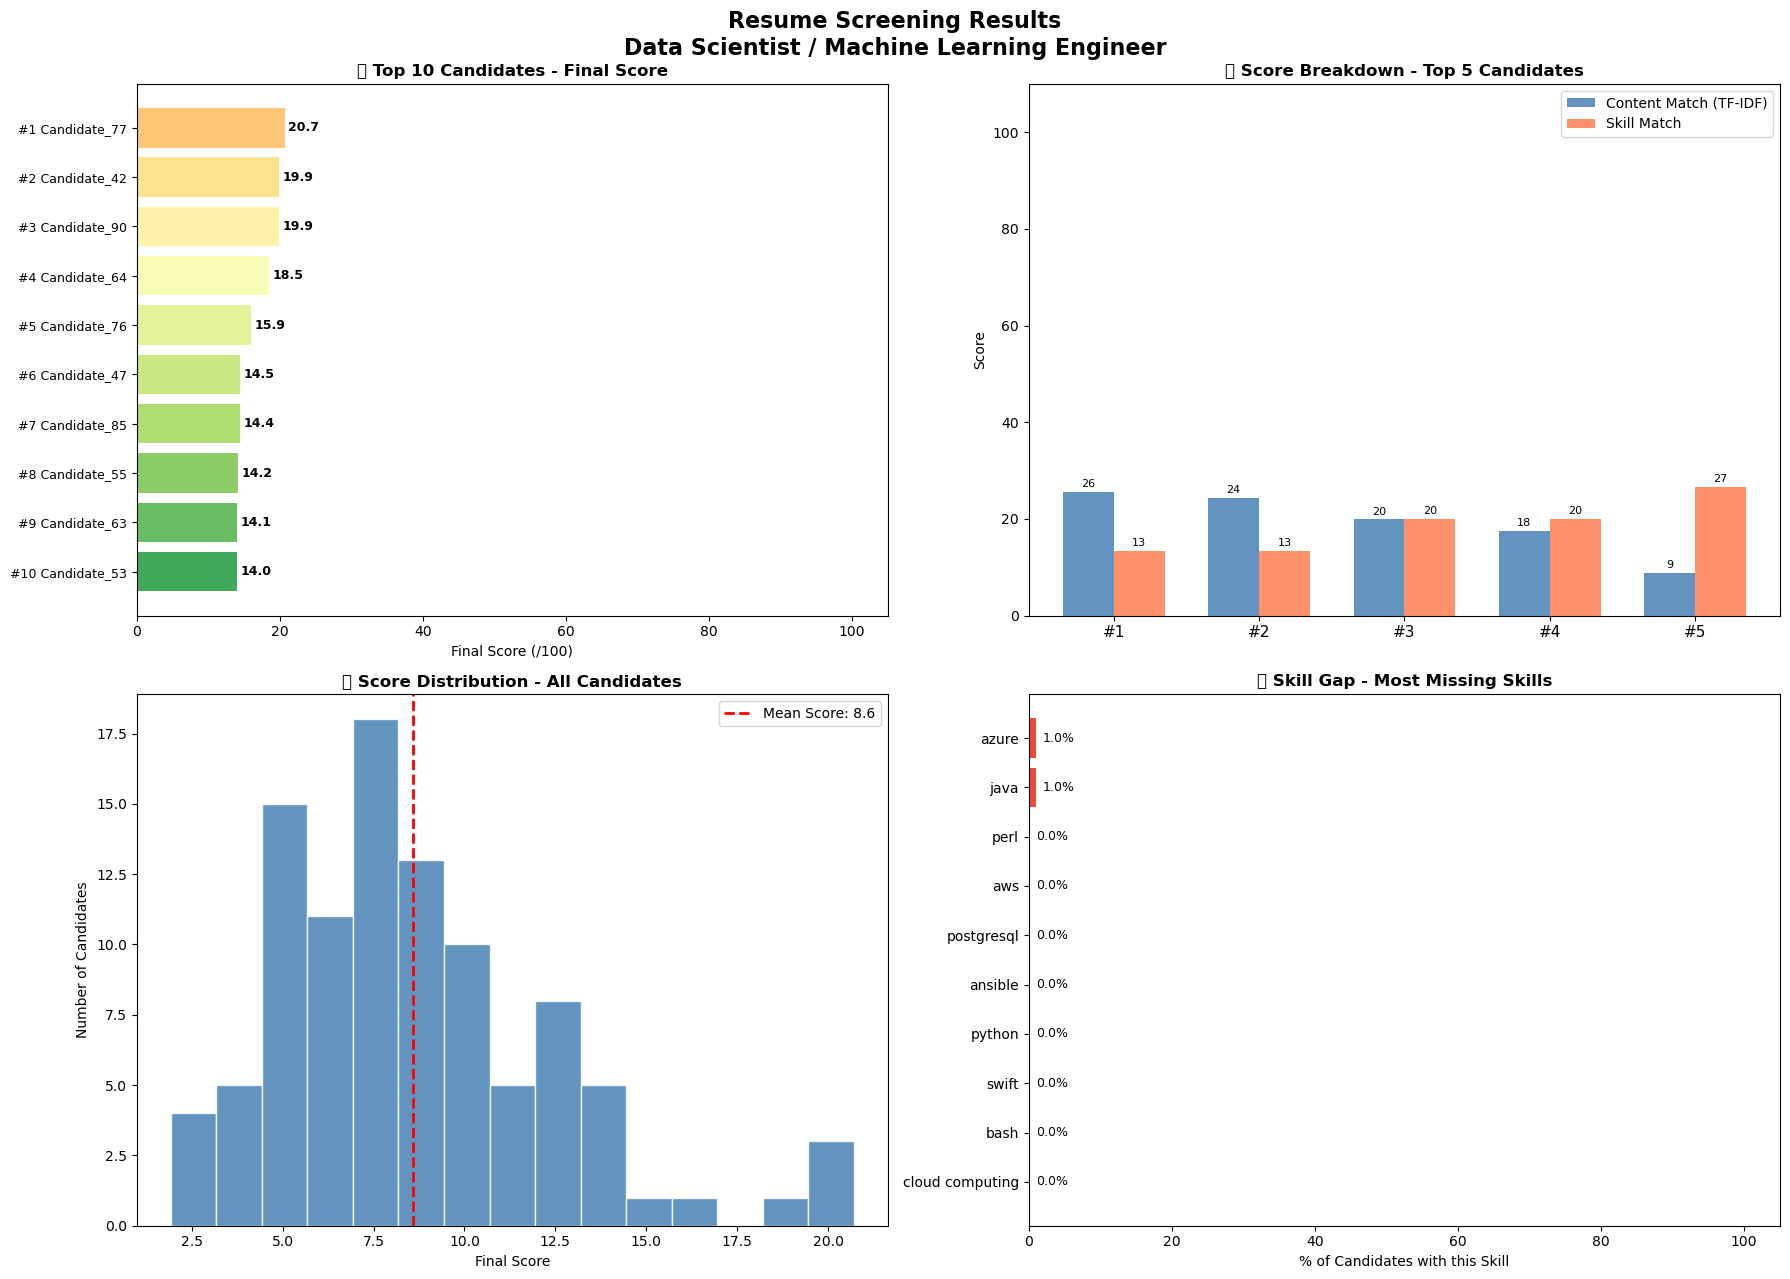


✅ All 4 Charts created and saved to output/screening_results.png


In [15]:
# ============================================================
# PART 12: VISUALIZATIONS - 4 CHARTS
# ============================================================

import os
os.makedirs('output', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    f'Resume Screening Results\n{JOB_ROLE}',
    fontsize=16, fontweight='bold', y=0.98
)

top10 = results_df.head(10).copy()
colors_green = plt.cm.RdYlGn(np.linspace(0.35, 0.85, len(top10)))

# ---- CHART 1: Top Candidates Final Score ----
ax1 = axes[0, 0]
bars = ax1.barh(
    range(len(top10)),
    top10['Final_Score'],
    color=colors_green
)
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(
    [f"#{i+1} {name[:18]}" for i, name in enumerate(top10['Candidate'])],
    fontsize=9
)
ax1.set_xlabel('Final Score (/100)')
ax1.set_title('🏆 Top 10 Candidates - Final Score', fontweight='bold')
ax1.set_xlim(0, 105)
ax1.invert_yaxis()
for bar, score in zip(bars, top10['Final_Score']):
    ax1.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{score:.1f}', va='center', fontsize=9, fontweight='bold'
    )

# ---- CHART 2: Score Breakdown (TF-IDF vs Skill) ----
ax2 = axes[0, 1]
top5 = top10.head(5)
x = np.arange(len(top5))
w = 0.35
b1 = ax2.bar(x - w/2, top5['TF_IDF_Score'], w,
             label='Content Match (TF-IDF)', color='steelblue', alpha=0.85)
b2 = ax2.bar(x + w/2, top5['Skill_Score'], w,
             label='Skill Match', color='coral', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f'#{i+1}' for i in range(len(top5))], fontsize=11)
ax2.set_ylabel('Score')
ax2.set_ylim(0, 110)
ax2.set_title('📊 Score Breakdown - Top 5 Candidates', fontweight='bold')
ax2.legend()
for bar in b1:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{bar.get_height():.0f}', ha='center', fontsize=8)
for bar in b2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{bar.get_height():.0f}', ha='center', fontsize=8)

# ---- CHART 3: Score Distribution ----
ax3 = axes[1, 0]
ax3.hist(
    results_df['Final_Score'],
    bins=15, color='steelblue',
    edgecolor='white', alpha=0.85
)
mean_score = results_df['Final_Score'].mean()
ax3.axvline(mean_score, color='red', linestyle='--', linewidth=2,
            label=f'Mean Score: {mean_score:.1f}')
ax3.set_xlabel('Final Score')
ax3.set_ylabel('Number of Candidates')
ax3.set_title('📈 Score Distribution - All Candidates', fontweight='bold')
ax3.legend()

# ---- CHART 4: Skill Gap (Top Missing Skills) ----
ax4 = axes[1, 1]
if jd_skills:
    skill_cov = {}
    for skill in jd_skills:
        count = sum(1 for s in results_df['All_Skills'] if skill in s)
        skill_cov[skill] = round((count / len(results_df)) * 100, 1)
    
    # Show bottom 10 (most missing skills)
    skill_cov_sorted = dict(sorted(skill_cov.items(), key=lambda x: x[1])[:10])
    
    skill_colors = ['#e74c3c' if v < 30 else '#f39c12' if v < 60
                    else '#27ae60' for v in skill_cov_sorted.values()]
    
    ax4.barh(
        list(skill_cov_sorted.keys()),
        list(skill_cov_sorted.values()),
        color=skill_colors
    )
    ax4.set_xlabel('% of Candidates with this Skill')
    ax4.set_title('🛠️ Skill Gap - Most Missing Skills', fontweight='bold')
    ax4.set_xlim(0, 105)
    for i, (skill, val) in enumerate(skill_cov_sorted.items()):
        ax4.text(val + 1, i, f'{val}%', va='center', fontsize=9)
else:
    ax4.text(0.5, 0.5, 'No JD skills\nto analyze',
             ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('output/screening_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ All 4 Charts created and saved to output/screening_results.png')

## PART 13: Save Results to CSV
**What this does:** We save all our results to a CSV file.
- This creates a file that can be opened in Excel
- Recruiters can use this file for their hiring decisions
- It's also required as part of the project submission
- We save it in the `output/` folder

In [16]:
# ============================================================
# PART 13: SAVE RESULTS TO CSV FILE
# ============================================================

import os
os.makedirs('output', exist_ok=True)

# Prepare clean output dataframe
output_df = results_df[[
    'Rank', 'Candidate', 'Final_Score',
    'TF_IDF_Score', 'Skill_Score', 'Skills_Found'
]].copy()

# Convert lists to strings for CSV
output_df['Matched_Skills'] = results_df['Matched_Skills'].apply(
    lambda x: ', '.join(x) if x else 'None'
)
output_df['Missing_Skills'] = results_df['Missing_Skills'].apply(
    lambda x: ', '.join(x[:5]) if x else 'None'
)

# Add fit label
def get_fit_label(score):
    if score >= 70: return 'Strong Fit'
    elif score >= 50: return 'Moderate Fit'
    elif score >= 30: return 'Weak Fit'
    else: return 'Not Fit'

output_df['Fit_Label'] = output_df['Final_Score'].apply(get_fit_label)

# Save to CSV
output_path = 'output/candidate_rankings.csv'
output_df.to_csv(output_path, index=False)

print('=' * 55)
print('  💾 RESULTS SAVED SUCCESSFULLY!')
print('=' * 55)
print(f'  File saved : {output_path}')
print(f'  Total rows : {len(output_df)}')
print()
print('Preview of saved file:')
display(output_df.head(10))

print()
print('  Fit Label Summary:')
print(output_df['Fit_Label'].value_counts())

  💾 RESULTS SAVED SUCCESSFULLY!
  File saved : output/candidate_rankings.csv
  Total rows : 100

Preview of saved file:


,Rank,Candidate,Final_Score,TF_IDF_Score,Skill_Score,Skills_Found,Matched_Skills,Missing_Skills,Fit_Label
0,1,Candidate_77,20.70,25.62,13.33,8,"linux, communication","r, cloud computing, java, bash, swift",Not Fit
1,2,Candidate_42,19.95,24.36,13.33,7,"communication, excel","r, cloud computing, java, linux, bash",Not Fit
2,3,Candidate_90,19.93,19.89,20.00,9,"sql, communication, excel","r, cloud computing, java, linux, bash",Not Fit
3,4,Candidate_64,18.51,17.51,20.00,3,"linux, communication, azure","r, cloud computing, java, bash, swift",Not Fit
4,5,Candidate_76,15.94,8.79,26.67,4,"r, sql, communication, excel","cloud computing, java, linux, bash, swift",Not Fit
5,6,Candidate_47,14.49,19.70,6.67,2,communication,"r, cloud computing, java, linux, bash",Not Fit
6,7,Candidate_85,14.42,10.70,20.00,7,"java, sql, excel","r, cloud computing, linux, bash, swift",Not Fit
7,8,Candidate_55,14.19,14.77,13.33,4,"sql, excel","r, cloud computing, java, linux, bash",Not Fit
8,9,Candidate_63,14.07,14.56,13.33,4,"communication, excel","r, cloud computing, java, linux, bash",Not Fit
9,10,Candidate_53,13.97,14.40,13.33,2,"communication, excel","r, cloud computing, java, linux, bash",Not Fit



  Fit Label Summary:
Fit_Label
Not Fit    100
Name: count, dtype: int64


## PART 14: Final Summary Report
**What this does:** A clean summary of everything our system did.
- Shows key statistics
- Highlights top recommended candidates
- This is what you would present to a recruiter or HR manager
- It makes our ML system explainable to non-technical users

In [17]:
# ============================================================
# PART 14: FINAL SUMMARY REPORT
# ============================================================

strong  = len(output_df[output_df['Fit_Label'] == 'Strong Fit'])
moderate = len(output_df[output_df['Fit_Label'] == 'Moderate Fit'])
weak    = len(output_df[output_df['Fit_Label'] == 'Weak Fit'])
not_fit = len(output_df[output_df['Fit_Label'] == 'Not Fit'])

print('=' * 60)
print('  📋 FINAL SUMMARY REPORT')
print('  Future Interns - ML Task 3: Resume Screening System')
print('=' * 60)
print()
print(f'  🎯 Job Role    : {JOB_ROLE}')
print(f'  👥 Total Screened   : {len(results_df)} candidates')
print(f'  📊 Average Score    : {results_df["Final_Score"].mean():.1f} / 100')
print(f'  🏆 Highest Score    : {results_df["Final_Score"].max():.1f} / 100')
print()
print('  Candidate Categories:')
print(f'  🟢 Strong Fit   (70+) : {strong} candidates')
print(f'  🟡 Moderate Fit (50+) : {moderate} candidates')
print(f'  🟠 Weak Fit     (30+) : {weak} candidates')
print(f'  🔴 Not Fit      (<30) : {not_fit} candidates')
print()
print('  🏆 TOP 3 RECOMMENDED CANDIDATES:')
print('  ' + '-' * 50)
for _, row in results_df.head(3).iterrows():
    print(f'  #{int(row["Rank"])} {row["Candidate"]}')
    print(f'     Score: {row["Final_Score"]:.1f}/100 | '
          f'Skills Found: {row["Skills_Found"]}')
    if row['Matched_Skills']:
        print(f'     Key Skills: {", ".join(row["Matched_Skills"][:5])}')
    print()
print('  📁 Output Files:')
print('  ✅ output/candidate_rankings.csv  - Full ranked list')
print('  ✅ output/screening_results.png   - Charts & graphs')
print()
print('  🔧 How Scoring Works:')
print('  ┌─────────────────────────────────────────┐')
print('  │  Final Score = TF-IDF(60%) + Skill(40%) │')
print('  │  TF-IDF = Text content similarity        │')
print('  │  Skill  = Required skills matched        │')
print('  └─────────────────────────────────────────┘')
print()
print('=' * 60)
print('  ✅ RESUME SCREENING SYSTEM - COMPLETE!')
print('  Ready for GitHub submission as FUTURE_ML_03')
print('=' * 60)

  📋 FINAL SUMMARY REPORT
  Future Interns - ML Task 3: Resume Screening System

  🎯 Job Role    : Data Scientist / Machine Learning Engineer
  👥 Total Screened   : 100 candidates
  📊 Average Score    : 8.6 / 100
  🏆 Highest Score    : 20.7 / 100

  Candidate Categories:
  🟢 Strong Fit   (70+) : 0 candidates
  🟡 Moderate Fit (50+) : 0 candidates
  🟠 Weak Fit     (30+) : 0 candidates
  🔴 Not Fit      (<30) : 100 candidates

  🏆 TOP 3 RECOMMENDED CANDIDATES:
  --------------------------------------------------
  #1 Candidate_77
     Score: 20.7/100 | Skills Found: 8
     Key Skills: linux, communication

  #2 Candidate_42
     Score: 19.9/100 | Skills Found: 7
     Key Skills: communication, excel

  #3 Candidate_90
     Score: 19.9/100 | Skills Found: 9
     Key Skills: sql, communication, excel

  📁 Output Files:
  ✅ output/candidate_rankings.csv  - Full ranked list
  ✅ output/screening_results.png   - Charts & graphs

  🔧 How Scoring Works:
  ┌─────────────────────────────────────────┐